In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme, norm, expon, pareto, uniform, cauchy

In [3]:
def block_maxima(x, block_size):
    n_blocks = len(x) // block_size
    return x[:n_blocks * block_size].reshape(n_blocks, block_size).max(axis=1)


def plot_gev_fit(maxima, title):
    xi, loc, scale = genextreme.fit(maxima)
    x = np.linspace(maxima.min(), maxima.max(), 500)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(maxima, bins=40, density=True, alpha=0.5, label='block maxima')
    ax.plot(x, genextreme.pdf(x, xi, loc, scale), lw=2,
            label=f'GEV fit  ξ={xi:.3f}')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'ξ={xi:.4f}  loc={loc:.4f}  scale={scale:.4f}')
    return xi

## Тип I — Гумбель (ξ = 0)

Распределения с лёгкими хвостами (нормальное, экспоненциальное) порождают максимумы, сходящиеся к Гумбелю.

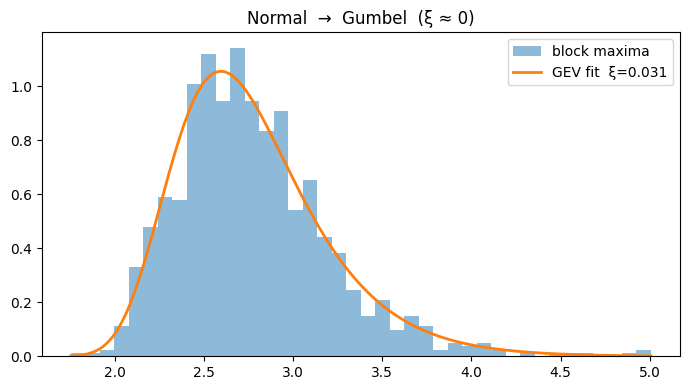

ξ=0.0311  loc=2.5834  scale=0.3487


In [4]:
# Normal → Gumbel  (ξ → 0)
rng = np.random.default_rng(42)
sample = norm.rvs(size=200_000, random_state=rng)
maxima = block_maxima(sample, block_size=200)
plot_gev_fit(maxima, 'Normal  →  Gumbel  (ξ ≈ 0)');

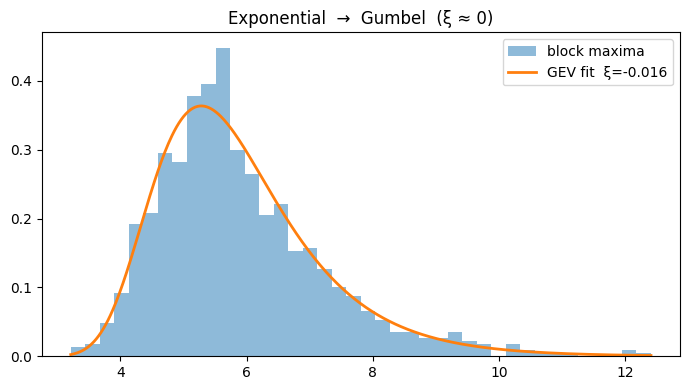

ξ=-0.0159  loc=5.2982  scale=1.0116


In [5]:
# Exponential → Gumbel  (ξ → 0)
rng = np.random.default_rng(42)
sample = expon.rvs(size=200_000, random_state=rng)
maxima = block_maxima(sample, block_size=200)
plot_gev_fit(maxima, 'Exponential  →  Gumbel  (ξ ≈ 0)');

## Тип II — Фреше (ξ > 0)

Распределения с тяжёлыми хвостами (Парето с параметром α, Коши). Теоретически ξ = 1/α для Парето.

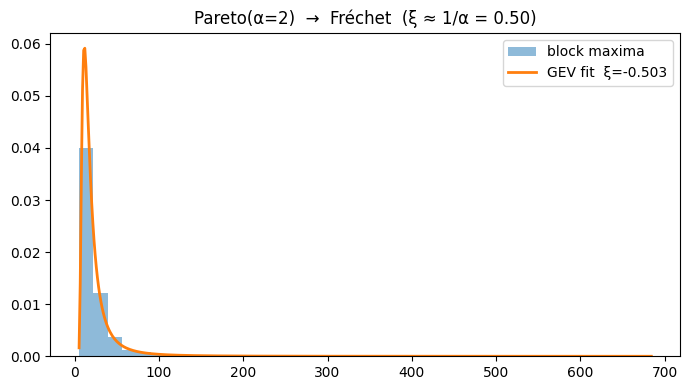

ξ=-0.5031  loc=14.0861  scale=6.8810


In [6]:
# Pareto(α=2) → Fréchet  (ξ → 1/α = 0.5)
alpha = 2
rng = np.random.default_rng(42)
sample = pareto.rvs(b=alpha, size=200_000, random_state=rng)
maxima = block_maxima(sample, block_size=200)
plot_gev_fit(maxima, f'Pareto(α={alpha})  →  Fréchet  (ξ ≈ 1/α = {1/alpha:.2f})');

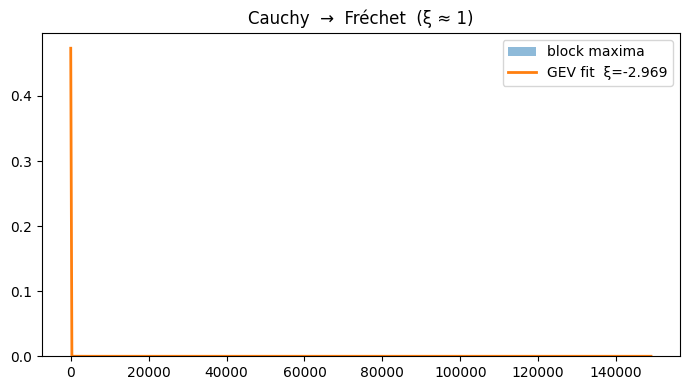

ξ=-2.9695  loc=11.7057  scale=7.7428


In [7]:
# Cauchy → Fréchet  (ξ → 1)
rng = np.random.default_rng(42)
sample = cauchy.rvs(size=200_000, random_state=rng)
maxima = block_maxima(sample, block_size=200)
plot_gev_fit(maxima, 'Cauchy  →  Fréchet  (ξ ≈ 1)');

## Тип III — Вейбулл (ξ < 0)

Распределения, ограниченные сверху (равномерное). Теоретически ξ = −1 для Uniform[0, 1].

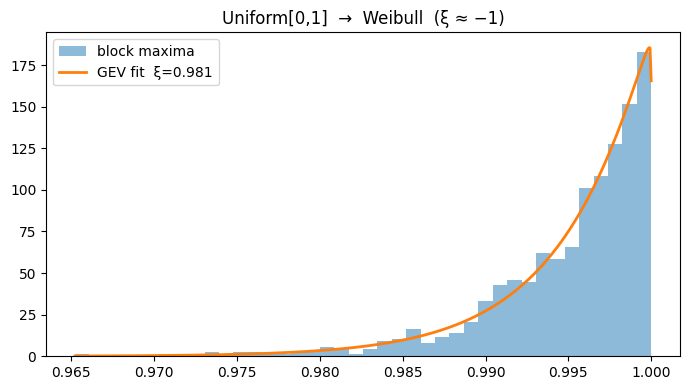

ξ=0.9808  loc=0.9950  scale=0.0049


In [8]:
# Uniform[0,1] → Weibull  (ξ → -1)
rng = np.random.default_rng(42)
sample = uniform.rvs(size=200_000, random_state=rng)
maxima = block_maxima(sample, block_size=200)
plot_gev_fit(maxima, 'Uniform[0,1]  →  Weibull  (ξ ≈ −1)');

## Сходимость ξ по размеру блока

Для нормального распределения: чем больше блок, тем точнее оценка ξ стремится к 0.

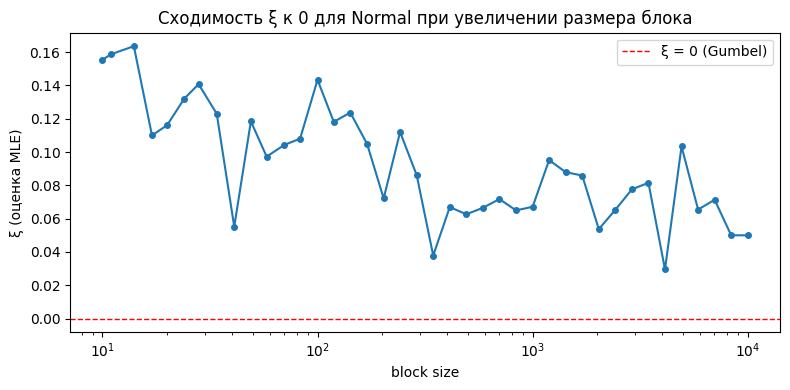

In [9]:
rng = np.random.default_rng(42)

MAX_BLOCKS = 1000  # не более 1000 максимумов на каждый fit
block_sizes = np.unique(np.logspace(1, 4, 40).astype(int))

xi_estimates = []
for bs in block_sizes:
    sample = norm.rvs(size=bs * MAX_BLOCKS, random_state=rng)
    m = block_maxima(sample, block_size=bs)  # ровно MAX_BLOCKS точек
    xi, _, _ = genextreme.fit(m)
    xi_estimates.append((bs, xi))

bs_arr, xi_arr = zip(*xi_estimates)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(bs_arr, xi_arr, marker='o', ms=4)
ax.axhline(0, color='red', ls='--', lw=1, label='ξ = 0 (Gumbel)')
ax.set_xlabel('block size')
ax.set_ylabel('ξ (оценка MLE)')
ax.set_title('Сходимость ξ к 0 для Normal при увеличении размера блока')
ax.legend()
plt.tight_layout()
plt.show()

## Интерактивный GEV

Ползунки меняют параметры распределения в реальном времени. Знак ξ определяет тип:

| ξ < 0 | ξ = 0 | ξ > 0 |
|--------|--------|--------|
| Вейбулл (ограничено сверху) | Гумбель | Фреше (тяжёлый хвост) |

In [14]:
import ipywidgets as widgets
from IPython.display import display

def plot_gev(xi, mu, sigma):
    if abs(xi) < 0.01:
        x_min = mu - 5 * sigma
        x_max = mu + 8 * sigma
    elif xi > 0:  # Фреше: нижняя граница μ - σ/ξ, хвост уходит вправо
        lower_bound = mu - sigma / xi
        x_min = lower_bound + 1e-6
        x_max = lower_bound + 15 * sigma
    else:         # Вейбулл: верхняя граница μ - σ/ξ, хвост уходит влево
        upper_bound = mu - sigma / xi
        x_min = upper_bound - 15 * sigma
        x_max = upper_bound - 1e-6

    x = np.linspace(x_min, x_max, 500)

    pdf = genextreme.pdf(x, -xi, loc=mu, scale=sigma)  # знак исправлен
    cdf = genextreme.cdf(x, -xi, loc=mu, scale=sigma)  # знак исправлен

    gev_type = 'Гумбель (ξ = 0)' if abs(xi) < 0.01 else ('Фреше (ξ > 0)' if xi > 0 else 'Вейбулл (ξ < 0)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(x, pdf, lw=2, color='steelblue')
    axes[0].fill_between(x, pdf, alpha=0.2, color='steelblue')
    axes[0].set_title(f'PDF — {gev_type}')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('плотность')
    axes[0].set_ylim(bottom=0)

    axes[1].plot(x, cdf, lw=2, color='darkorange')
    axes[1].set_title(f'CDF — {gev_type}')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_ylim(0, 1)

    fig.suptitle(f'GEV(ξ={xi:.2f}, μ={mu:.2f}, σ={sigma:.2f})', fontsize=13)
    plt.tight_layout()
    plt.show()

xi_slider    = widgets.FloatSlider(value=0.0,  min=-1.0, max=1.0,  step=0.05, description='ξ (xi)',    continuous_update=False, style={'description_width': '60px'})
mu_slider    = widgets.FloatSlider(value=0.0,  min=-5.0, max=5.0,  step=0.1,  description='μ (mu)',    continuous_update=False, style={'description_width': '60px'})
sigma_slider = widgets.FloatSlider(value=1.0,  min=0.1,  max=5.0,  step=0.1,  description='σ (sigma)', continuous_update=False, style={'description_width': '60px'})

out = widgets.interactive_output(plot_gev, {'xi': xi_slider, 'mu': mu_slider, 'sigma': sigma_slider})
display(widgets.VBox([xi_slider, mu_slider, sigma_slider, out]))